In [1]:
import langgraph
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

from config import Config
from pydantic import BaseModel, Field
from typing import Annotated
from langgraph.graph.message import add_messages
from prompts import BOSS_AGENT_PROMPT, PLANE_AGENT_PROMPT, ACCOMMODATIONS_AGENT_PROMPT, ITINERARY_AGENT_PROMPT
import gradio as gr
from langchain_core.globals import set_verbose
set_verbose(True)

config = Config()


/Users/rodrigo/Desktop/work_projects/AI_training/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
llm = config.get_llm()

### Multi Agent System for Travel Planner
In this demo we will build a multi agent system that will act as a travel agency. The idea is to have a chat interface in which the user can talk with the travel agent to describe his or her ideal, but realistic trip, subject to constraints of time, budget, availability, etc.

Our system will consist of an orchestrator agent, which is in charge of talking directly to the user. In the background, this agent leads a team of specialized agents, each responsible for one particular task:

- Itinerary agent
- Activities agent
- plane browsing agent
- accomodations agent

In [3]:
class State(BaseModel):
    messages: Annotated[list, add_messages] = Field(default_factory=list)
    origin: str = Field(default="")
    destination: str = Field(default="")



In [ ]:
from langchain_core.tools import tool

@tool
def search_flights(origin: str, destination: str, date: str) -> list[dict]:
    """Search for available flights between two cities on a given date."""
    return [
        {"airline": "Air France", "departure": "08:30", "arrival": "14:45", "stops": 1, "price": 420},
        {"airline": "Iberia", "departure": "11:00", "arrival": "16:30", "stops": 0, "price": 530},
        {"airline": "Lufthansa", "departure": "06:15", "arrival": "13:00", "stops": 1, "price": 380},
    ]

@tool
def search_hotels(destination: str, checkin: str, checkout: str) -> list[dict]:
    """Search for hotels in a destination."""
    return [
        {"name": "Hotel Central", "location": "City center", "nightly_rate": 95, "rating": 4.2},
        {"name": "Grand Palace", "location": "Old town", "nightly_rate": 150, "rating": 4.7},
        {"name": "Budget Inn", "location": "Near station", "nightly_rate": 55, "rating": 3.8},
    ]

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.prebuilt import ToolNode, tools_condition

def orchestrator_node(state: State) -> dict:
    messages = [{"role": "system", "content": BOSS_AGENT_PROMPT}] + state.messages
    response = llm.invoke(messages)
    return {"messages": [response]}


def plane_agent_node(state: State) -> dict:
    llm_plane_with_tools = llm.bind_tools([search_flights])
    messages = [{"role": "system", "content": PLANE_AGENT_PROMPT}] + state.messages
    response = llm_plane_with_tools.invoke(messages)
    return {"messages": [response]}


def accommodations_agent_node(state: State) -> dict:
    llm_accommodations_with_tools = llm.bind_tools([search_hotels])
    messages = [{"role": "system", "content": ACCOMMODATIONS_AGENT_PROMPT}] + state.messages
    response = llm_accommodations_with_tools.invoke(messages)
    return {"messages": [response]}

def summary_agent_node(state: State) -> dict:
    messages = [{"role": "system", "content": ITINERARY_AGENT_PROMPT}] + state.messages
    response = llm.invoke(messages)
    return {"messages": [response]}


# Routing: orchestrator decides which specialist to call, or returns to user
def route_from_orchestrator(state: State) -> str:
    last_msg = state.messages[-1]
    content = getattr(last_msg, "content", "")
    if "HANDOFF:PLANE" in content:
        return "plane_agent"
    if "HANDOFF:ACCOMMODATIONS" in content:
        return "accommodations_agent"
    if "HANDOFF:SUMMARY" in content:
        return "summary_agent"
    return END  # stay in conversation with the user


memory = MemorySaver()
graph = StateGraph(State)

graph.add_node("orchestrator", orchestrator_node)
graph.add_node("plane_agent", plane_agent_node)

graph.add_node("plane_search_tool", ToolNode(tools=[search_flights]))


graph.add_node("accommodations_agent", accommodations_agent_node)

graph.add_node("accommodations_search_tool", ToolNode(tools=[search_hotels]))
graph.add_node("summary_agent", summary_agent_node)
    
graph.add_edge(START, "orchestrator")

# Orchestrator routes to the right specialist or END
graph.add_conditional_edges("orchestrator", route_from_orchestrator, {
    "plane_agent": "plane_agent",
    "accommodations_agent": "accommodations_agent",
    "summary_agent": "summary_agent",
    END: END,
})

# Plane agent loops with tool, then returns to orchestrator
graph.add_conditional_edges("plane_agent", tools_condition, {"tools": "plane_search_tool", END: "orchestrator"})
graph.add_edge("plane_search_tool", "plane_agent")

# Accommodations agent loops with tool, then returns to orchestrator
graph.add_conditional_edges("accommodations_agent", tools_condition, {"tools": "accommodations_search_tool", END: "orchestrator"})
graph.add_edge("accommodations_search_tool", "accommodations_agent")

# Summary agent returns to END
graph.add_edge("summary_agent", END)

app = graph.compile(checkpointer=memory)

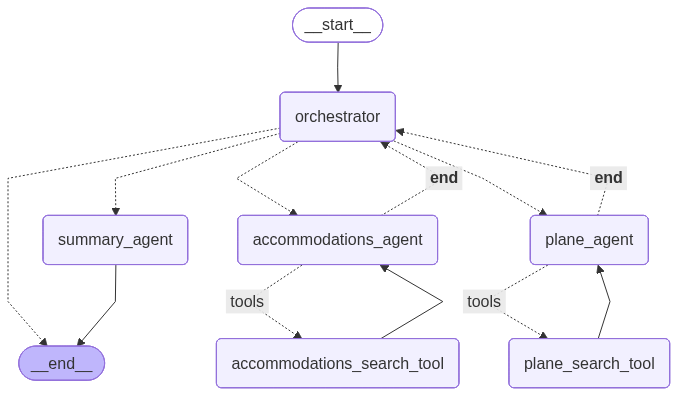

In [7]:
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
thread_config = {"configurable": {"thread_id": "1"}}


def chat_stream(user_input: str, history) -> str:
    for event in app.stream(
        {"messages": [{"role": "user", "content": user_input}]},
        config=thread_config,
        stream_mode="updates",
    ):
        # event is a dict like {"orchestrator": {"messages": [...]}}
        for node_name, updates in event.items():
            print(f"--- {node_name} ---")
            for msg in updates.get("messages", []):
                if hasattr(msg, "tool_calls") and msg.tool_calls:
                    print(f"  Tool calls: {msg.tool_calls}")
                elif hasattr(msg, "content"):
                    print(f"  {msg.content[:200]}")
    # Get final state for the return value
    state = app.get_state(thread_config)
    return state.values["messages"][-1].content

In [9]:
# thread_id groups all messages into one conversation.
# LangGraph's checkpointer saves the full State after each invoke.
# You only send the NEW message — the checkpointer provides the history.
thread_config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history) -> str:
    result = app.invoke({"messages": [{"role": "user", "content": user_input}]},
                        config=thread_config,
    )
    return result["messages"][-1].content

In [10]:
gr.ChatInterface(chat_stream).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


--- orchestrator ---
  That sounds amazing! Japan is a fantastic destination. To get started, could you tell me where you're traveling from (your origin city and country)?
--- orchestrator ---
  Got it! You're flying from Munich in the first two weeks of September. Could you confirm if you're planning to stay in one city in Japan, or would you like to visit multiple destinations? If multiple,
--- orchestrator ---
  Lovely! Japan has some incredible cities to explore. A typical multi-city itinerary could include Tokyo (for its vibrant metropolis vibe), Kyoto (for rich culture and temples), Osaka (for food and nig
--- orchestrator ---
  Great, thanks for the budget info! So, we're planning a two-week trip to Japan in the first two weeks of September, starting from Munich, exploring multiple cities — Tokyo, Kyoto, Osaka, and Hiroshima
--- orchestrator ---
  Perfect! Japan is phenomenal for both its culinary scene and rich history. Think sushi, ramen, and street food in Osaka, paired with 